# 6.5. Word2Vec

## Skip-gram

**<임베딩 클래스>**
- V: 학습할 단어의 수
- E: 임베딩 차원
- $W_{V*E}$ 행렬과 $W’_{V*E}$ 행렬을 최적화하며 학습
- $W_{V*E}$  행렬은 룩업(Lookup) 연산을 수행 ⇒ 임베딩(Embedding) 클래스를 사용하여 간편하게 구현
    - 룩업 연산: 배열이나 리스트 등의 데이터 구조에서 인덱스를 이용해 해당하는 값을 찾아오는 연산
- 임베딩 클래스
  - 단어나 범주형 변수와 같은 이산 변수를 연속적인 벡터로 변환해 사용
  - 연속적인 벡터 표현은 모델이 학습하는 동안 단어의 의미와 관련된 정포를 포착, 이를 기반으로 단어 간의 유사도 계산
  - 룩업: 이산 변수 값을 연속적인 벡터로 변환하는 과정



```
embedding = torch.nn.Embedding(
    num_embeddings,
    embedding_dim,
    padding_idx=None,
    max_norm=None,
    norm_type=2.0
)
```
  - 임베딩 수(num_embeddings)
    - 이산 변수의 개수
    - 단어 사전의 크기
  - 임베딩 차원(embedding_dim)
    - 임베딩 벡터의 차원 수
    - 임베딩 벡터의 크기
  - 패딩 인덱스(padding_idx)
    - 패딩 토큰의 인덱스를 지정해 해당 인덱스 벡터를 0으로 설정
    - 병렬 처리를 위해 입력 배치의 문장 길이가 동일해야 하므로 입력 문장들을 일정한 길이로 맞추는 역할
    - 임베딩 수보다 작아야 함
    - 패딩 인덱스의 벡터값은 모델 학습 시 최적화되지 않음
  - 노름 타입(norm_type)
    - 임베딩 벡터의 크기를 제한하는 방법
    - 기본값: 2 => L2 정규화
    - 1로 설정 => L1 정규화
  - 최대 노름(max_norm)
    - 임베딩 벡터의 최대 크기 지정
    - 각 임베딩 벡터의 크기가 최대 노름 값 이상이면 임베딩 벡터를 최대 노름 크기로 잘라내고 크기를 감소시킴


### 기본 Skip-gram 클래스
- 임베딩 클래스 => 룩업 계층 구현
- 선형 변화 클래스 => 가중치 행렬 구현

In [29]:
from torch import nn

class VanillaSkipgram(nn.Module):
  def __init__(self, vocab_size, embedding_dim):
    super().__init__()
    self.embedding = nn.Embedding(
        num_embeddings=vocab_size,
        embedding_dim=embedding_dim
    )

    self.linear = nn.Linear(
        in_features=embedding_dim,
        out_features=vocab_size
    )

  def forward(self, input_ids):
    embeddings = self.embedding(input_ids)
    output = self.linear(embeddings)
    return output

- 계층적 소프트맥스, 네거티브 샘플링과 같은 효율적인 기법을 사용하지 않은 기본 형식의 Skip-gram 모델은 간단히 구현 가능
- 단순히 입력 단어, 주변 단어를 룩업 테이블에서 가져와서 내적 계산 -> 손실 함수를 통해 예측 오차를 최소화하는 방식으로 학습

### 영화 리뷰 데이터세트 전처리
- 데이터세트: 코포라 라이브러리의 네이버 영화 리뷰 감정 분석 데이터세트

In [4]:
!apt-get update
!apt-get install -y openjdk-8-jdk

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,683 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,726 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,948 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy

In [5]:
!pip install Korpora
!pip install konlpy

In [23]:
import pandas as pd
from Korpora import Korpora
from konlpy.tag import Okt

corpus = Korpora.load("nsmc")
corpus = pd.DataFrame(corpus.test)

tokenizer = Okt()
tokens = [tokenizer.morphs(review) for review in corpus.text]
print(tokens[:3])


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : e9t@github
    Repository : https://github.com/e9t/nsmc
    References : www.lucypark.kr/docs/2015-pyconkr/#39

    Naver sentiment movie corpus v1.0
    This is a movie review dataset in the Korean language.
    Reviews were scraped from Naver Movies.

    The dataset construction is based on the method noted in
    [Large movie review dataset][^1] from Maas et al., 2011.

    [^1]: http://ai.stanford.edu/~amaas/data/sentiment/

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/

[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ratings_train.txt
[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ra

- 크기가 작은 테스트 데이터세트를 활용해 실습 진행
- `corpus.test`
  - 테스트 세트 로드
- Okt 토크나이저
  - 형태소 추출

### 단어 사전 구축

In [24]:
from collections import Counter

def build_vocab(corpus, n_vocab, special_tokens):
  counter = Counter()
  for tokens in corpus:
    counter.update(tokens)
  vocab = special_tokens
  for token, count in counter.most_common(n_vocab):
    vocab.append(token)
  return vocab

vocab = build_vocab(corpus=tokens, n_vocab=5000, special_tokens=["<unk>"])
token_to_id = {token: idx for idx, token in enumerate(vocab)}
id_to_token = {idx: token for idx, token in enumerate(vocab)}

print(vocab[:10])
print(len(vocab))

['<unk>', '.', '이', '영화', '의', '..', '가', '에', '...', '을']
5001


- Okt 토크나이저를 통해 토큰화된 데이터 활용

**<build_vocab 함수>**
- 단어 사전 구축
- `n_vocab` 매개변수
  - 구축할 단어 사전의 크기
  - 문서 내에 n_vocab보다 많은 종류의 토큰이 있다면, 가장 많이 등장한 토큰 순서로 사전을 구축
- `special tokens` 매개변수
  - 특별한 의미를 갖는 토큰들
  - \<unk>: OOV에 대응하기 위한 토큰

    => 단어 사전에 없는 모든 단어는 <unk> 토큰으로 대체
- 예제에서 단어 사전 최대 길이는 5000, 특수 토큰은 1개 => 단어 사전은 5001개로 구성


### 단어 쌍 추출
- 윈도 크기 정의
- 학습에 사용할 단어 쌍 추출
- 예제) 중심 단어의 앞, 뒤 두 단어를 윈도로 하여 단어 쌍 추출 방식을 보여줌


In [25]:
def get_word_pairs(tokens, window_size):
  pairs = []
  for sentence in tokens:
    sentence_length = len(sentence)

    for idx, center_word in enumerate(sentence):
      window_start = max(0, idx-window_size)
      window_end = min(sentence_length, idx+window_size+1)
      center_word = sentence[idx]
      context_words = sentence[window_start:idx] + sentence[idx+1:window_end]
      for context_word in context_words:
        pairs.append([center_word, context_word])
  return pairs

word_pairs = get_word_pairs(tokens, window_size=2)
print(word_pairs[:5])

[['굳', 'ㅋ'], ['ㅋ', '굳'], ['뭐', '야'], ['뭐', '이'], ['야', '뭐']]


**<get_word_pairs 함수>**
- 토큰을 입력받아 skip-gram 모델의 입력 데이터로 사용할 수 있게 전처리
- `window_size` 매개변수
  - 주변 단어를 몇 개까지 고려할 것인지 설정
  - 각 문장에서는 중심 단어와 주변 단어를 고려하여 쌍 생성
- `idx`
  - 현재 단어의 인덱스
- `center_word`
  - 중심 단어
- `window_start`, `window_end`
  - 현재 단어에서 얼마나 멀리 떨어진 주변 단어를 고려할 것인지를 결정
  - 문장의 경계를 넘어가는 경우가 없게 조정
- 출력
  - [중심 단어, 주변 단어]로 구성


### 인덱스 쌍 변환
- 임베딩 층은 단어의 인덱스를 입력으로 받기 때문에 단어 쌍을 인덱스 쌍으로 변환해야 함

In [26]:
def get_index_pairs(word_pairs, token_to_id):
  pair = []
  unk_index = token_to_id["<unk>"]

  for word_pairs in word_pairs:
    center_word, context_word = word_pairs
    center_index = token_to_id.get(center_word, unk_index)
    context_index = token_to_id.get(context_word, unk_index)
    pair.append([center_index, context_index])
  return pair

index_pairs = get_index_pairs(word_pairs, token_to_id)
print(index_pairs[:5])

[[595, 100], [100, 595], [77, 176], [77, 2], [176, 77]]


**<get_index_pairs 함수>**
- `get_word_pairs` 함수에서 생성된 단어 쌍을 토큰 인덱스 쌍으로 변환
- 앞서 생성한 `word_pairs`와 단어와 단어에 해당하는 ID를 매핑한 딕셔너리인 `token_to_id`로 인덱스 쌍을 생성
- 딕셔너리의 `get` 메서드로 토큰이 단어 사전 내에 있으면 해당 토큰의 인덱스를 반환, 단어 사전 내에 없다면 \<unk> 토큰의 인덱스를 반환
- 생성된 인덱스 쌍은 Skip-gram 모델의 입력 데이터로 사용

### 데이터로더 적용
- 학습을 위해 텐서 형식으로 변환

In [27]:
import torch
from torch.utils.data import TensorDataset, DataLoader

index_pairs = torch.tensor(index_pairs)
center_index = index_pairs[:, 0]
context_index = index_pairs[:, 1]

dataset = TensorDataset(center_index, context_index)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

- index_pairs
  - get_index_pairs 함수에서 생성된 중심 단어와 주변 단어 토큰의 인덱스 쌍으로 이루어진 리스트
  - 이 리스트를 텐서 형식으로 변환
    - 텐서는 [N, 2] 구조를 가지므로 중심 단어와 주변 단어로 나눠 데이터세트로 변환

### 모델 준비 작업
- 모델을 학습하기 위해 필요한 작업 진행

In [30]:
from torch import optim

device = "cuda" if torch.cuda.is_available() else "cpu"
word2vec = VanillaSkipgram(vocab_size=len(token_to_id), embedding_dim=128).to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.SGD(word2vec.parameters(), lr=0.1)

- VanillaSkipgram 클래스의 단어 사전 크기(`vocab_size`)에 전체 단어 집합의 크기를 전달
- 임베딩 크기(`embedding_dim`): 128로 할당
- 손실 함수: 단어 사전 크기만큼 클래스가 있는 분류 문제이므로 교차 엔트로피 사용
  - 교차 엔트로피: 내부적으로 소프트맥스 연산을 수행하므로 신경망의 출력값을 후처리 없이 활용할 수 있음

### 모델 학습

In [31]:
for epoch in range(10):
  cost = 0.0
  for input_ids, target_ids in dataloader:
    input_ids = input_ids.to(device)
    target_ids = target_ids.to(device)

    logits = word2vec(input_ids)
    loss = criterion(logits, target_ids)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    cost += loss.item()

  cost = cost/len(dataloader)
  print(f"Epoch: {epoch+1:4d}, Cost: {cost:.3f}")

Epoch:    1, Cost: 6.195
Epoch:    2, Cost: 5.980
Epoch:    3, Cost: 5.931
Epoch:    4, Cost: 5.901
Epoch:    5, Cost: 5.879
Epoch:    6, Cost: 5.862
Epoch:    7, Cost: 5.847
Epoch:    8, Cost: 5.834
Epoch:    9, Cost: 5.823
Epoch:   10, Cost: 5.812


- 모델 학습이 끝나면 $W_{V*E}$ 행렬과 $W'_{E*V}$ 행렬 중 하나의 행렬을 선택해 임베딩 값 추출

### 임베딩 값 추출
- 파이토치의 임베딩 층으로 구현된 $W_{V*E}$ 행렬에서 임베딩 값 추출

In [32]:
token_to_embedding = dict()
embedding_matrix = word2vec.embedding.weight.detach().cpu().numpy()

for word, embedding in zip(vocab, embedding_matrix):
  token_to_embedding[word] = embedding

index = 30
token = vocab[30]
token_embedding = token_to_embedding[token]

print(token)
print(token_embedding)

연기
[-1.6380264e+00  3.1935361e-01  2.5240988e-01 -3.6557022e-01
 -1.4990088e+00  6.3850415e-01  1.0901040e+00  1.6117961e+00
 -4.1562542e-01 -9.0519542e-01  1.0890340e-01  1.6094832e+00
 -2.8078848e-01 -1.3049313e-01 -2.1493270e-01  6.9981396e-01
  1.0878759e-03 -3.3648929e-01 -1.1206678e+00 -4.0434983e-01
 -2.9444247e-01  1.6299125e+00  1.8897012e+00 -9.6439892e-01
  3.3037040e-01 -1.7156336e+00 -5.8567899e-01  6.9698608e-01
 -7.8176278e-01 -1.4869729e-01  2.5050804e-01  5.1796448e-01
  7.8981310e-01 -8.6839283e-01 -1.8689386e+00 -8.8244522e-01
 -1.1155773e+00  1.4666298e-01  2.3578340e-03  1.7048225e-02
  1.2143505e+00  9.3696696e-01  1.8507347e-01 -3.3762526e-02
 -1.7357612e-01 -5.1853156e-01 -6.6186167e-02  1.0882163e+00
 -9.2041388e-02  4.6117052e-01  1.2176338e-01  4.9275360e-01
  2.8093925e-01 -6.1724257e-01 -1.5186948e+00 -4.1268107e-01
  4.4461810e-03 -5.9889829e-01  7.2647768e-01 -4.3838477e-01
 -6.3782740e-01  2.2438577e-01  8.6040336e-01  1.2748422e-01
 -7.9388618e-01 -2.01

**<임베딩 값>**
- Word2Vec 모델의 임베딩 행렬을 이용해 각 단어의 임베딩 값을 매핑
- 인덱스 30 값의 단어와 임베딩 값 출력
- 임베딩 값으로 단어 간의 유사도를 확인할 수 있음

  => 코사인 유사도를 많이 사용

**<코사인 유사도(Cosine Similarity)>**
- 두 벡터 간의 각도를 이용하여 유사도를 계산
- 두 벡터가 유사할수록 값이 1에 가까워지고, 다를수록 0에 가까워짐
- 두 벡터의 내적을 벡터의 크기(유클리드 노름)의 곱으로 나누어 계산
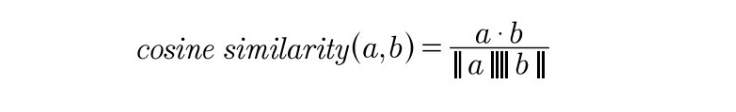
  - a, b: 유사도를 계산하려는 벡터
  - 벡터의 크기: 각 성분의 제곱합에 루트를 씌운 값
  - 두 벡터를 내적한 벡터의 크기의 곱을 나눠 계산
- 임베딩 공간에서 단어 간의 유사도를 측정하는 데 매우 유용

### 단어 임베딩 유사도 계산
- 코사인 유사도로 특정 단어와 가장 유사한 단어를 출력
- 넘파이의 선형대수 라이브러리를 활용해 벡터와 벡터의 코사인 유사도, 벡터와 행렬의 코사인 유사도를 계산

In [33]:
import numpy as np
from numpy.linalg import norm

def cosine_similarity(a, b):
  cosine = np.dot(b, a) / (norm(b, axis=1)*norm(a))
  return cosine

def top_n_index(cosine_matrix, n):
  closest_indexes = cosine_matrix.argsort()[::-1]
  top_n = closest_indexes[1:n+1]
  return top_n

cosine_matrix = cosine_similarity(token_embedding, embedding_matrix)
top_n = top_n_index(cosine_matrix, n=5)

print(f"{token}과 가장 유사한 5개 단어")
for index in top_n:
  print(f"{id_to_token[index]} - 유사도: {cosine_matrix[index]:.4f}")

연기과 가장 유사한 5개 단어
모두 - 유사도: 0.2909
남네요 - 유사도: 0.2849
잤다 - 유사도: 0.2753
헐리우드 - 유사도: 0.2666
보았지만 - 유사도: 0.2644


**<cosine_similarity 함수>**
- 입력 단어와 단어 사전 내의 모든 단어와의 코사인 유사도 계산
- a 매개변수: 임베딩 토큰
- b 매개변수: 임베딩 행렬
  - [5001, 128] 구조를 가지므로 노름을 계산할 때 axis=1 방향으로 계산

**<top_n_index 함수>**
- 유사도 행렬을 내림차순으로 정렬해 어떤 단어가 가장 가까운 단어인지 반환
- 입력 단어도 단어 사전에 포함되므로 입력 단어 자신이 가장 가까운 단어가 됨

  => 두번째 가까운 단어부터 계산해 반환

## Gensim
- 매우 간단한 구조의 Word2Vec 모델을 학습할 때 데이터 수가 적어도 학습이 오래 걸림

  => 계층적 소프트맥스, 네거티브 샘플링 기법을 사용하면 더 효율적으로 학습
- 젠심(Gensim) 라이브러리
  - Word2Vec 같은 자연어 처리 모델을 쉽게 구성할 수 있음
  - 대용량 텍스트 데이터의 처리를 위한 메모리 효율적인 방법을 제공

    => 대규모 데이터 세트에서도 효과적으로 모델을 학습
  - 학습된 모델을 저장하여 관리할 수 있음
  - 비슷한 단어 찾기 등 유사도와 관련된 기능 등 자연어 처리에 필요한 다양한 기능 제공

## 라이브러리 설치

In [ ]:
!pip install gensim

- 사이썬을 이용해 병렬 처리, 네거티브 샘플링 등을 적용
- 사이썬
  - C++ 기반의 확장 모듈을 파이썬 모듈로 컴파일하는 기능 제공
  - 젠심으로 모델을 구성하면 파이토치를 이용한 학습보다 훨씬 더 빠른 속도로 학습할 수 있음

**<Word2Vec 클래스>**
  - 네거티브 샘플링 등에 필요한 여러 하이퍼파라미터를 받아 쉽고 빠르게 모델을 학습할 수 있음
  ```
  word2vec = gensim.models.Word2Vec(
    sentences = None,
    corpus_file = None,
    vector_size = 100,
    alpha = 0.025,
    window = 5,
    min_count = 5,
    workers = 3,
    sg = 0,
    hs = 0,
    cbow_mean = 1,
    negative = 5,
    ns_exponent = 0.75,
    max_final_vocab = None,
    epochs = 5,
    batch_words = 10000
    )
  ```
  - 입력 문장(sentences)
    - 모델의 학습 데이터를 나타냄
    - 토큰 리스트로 표현
    - 이렇게 구성된 학습 데이터는 학습 문장들의 리스트로 이루어짐
  - 말뭉치 파일(corpus_file)
    - 학습 데이터를 파일로 입력할 때 파일의 경로
    - 입력 문장 대신 사용
  - 벡터 크기(vector_size)
    - 학습할 임베딩 벡터의 크기
    - 임베딩 차원 수를 설정
  - 학습률(alpha)
    - Word2Vec 모델의 학습률
  - 윈도(window)
    - 학습 데이터를 생성할 윈도의 크기
    - 윈도가 3이면 중심 단어로부터 3 떨어진 단어까지 주변 단어로 고려해 데이터를 생성
  - 최소 빈도(min_count)
    - 학습에 사용할 단어의 최소 빈도
    - 말뭉치 내에 최소 빈도만큼 등장하지 않은 단어는 학습에 사용되지 않음
  - 최대 최종 단어 사전(max_final_vocab)
    - 단어 사전의 최대 크기
    - 최소 빈도를 충족하는 단어가 최대 최종 단어 사전보다 많으면 자주 등장한 단어 순으로 단어 사전을 구축
  - 작업자 수(workers)
    - 빠른 학습을 위해 병렬 학습할 스레드의 수
  - Skip-gram(sg)
    - Skip-gram 모델의 사용 여부를 설정
    - 1이면 Skip-gram, 0이면 CBow 모델 사용
  - 계층적 소프트맥스(hs)
    - 계층적 소프트맥스 사용 여부를 설정
    - 1이면 사용
  - CBoW 평균화(cbow_mean)
    - CBoW 모델로 구성할 때 사용되는 하이퍼파라미터
    - 중심 단어와 주변 단어를 합쳐서 하나의 벡터로 만들 때, 합한 벡터의 평균화 여부를 설정
    - 1이면 평균화
  - 네거티브(negative)
    - 네거티브 샘플링의 단어 수
    - 0이면 사용하지 않음
  - 네거티브 지수(ns_exponent)
    - 네거티브 샘플링 확률의 지수
  - 에포크(epochs)
    - 학습 에포크 수
  - 배치 단어 수(batch_words)
    - 몇 개의 단어로 학습 배치를 구성할지 결정
    - 컴퓨팅 자원이 모자란다면 배치 단어 수를 낮추어 학습을 진행

## Word2Vec 모델 학습
- Word2Vec 클래스를 활용해 Skip-gram 모델을 학습하고 저장

In [ ]:
from gensim.models import Word2Vec

word2vec = Word2Vec(
    sentences = tokens,
    vector_size = 128,  # 임베딩 벡터의 크기
    window = 5, # 윈도우 크기
    min_count = 1,  # 최소 빈도는 고려하지 않음
    sg = 1,
    # 빠른 학습을 위해 네거티브 샘플링 사용
    epochs = 3,
    max_final_vocab = 10000 # 최대 단어 사전의 크기
)

# word2vec.save("/content/drive/MyDrive/word2vec.model")
# word2vec = Word2Vec.load("/content/drive/MyDrive/word2vec.model")

RecursionError: maximum recursion depth exceeded

- 영화 리뷰 데이터셋을 토큰화한 값을 입력
- VanillaSkipgram 클래스에 비해 매우 빠르게 학습됨
- word2vec 인스턴스는 파이토치의 저장 메서드와 동일한 방법으로 저장
- 파이토치 모델 파일과 구분하기 위해 *.model 형식으로 저장

### numpy, gensim 버전 충돌로 인한 fasttext 사용

In [21]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp311-cp311-linux_x86_64.whl size=4313501 sha256=fc31bd251c9a2dea435a835cc3168909d59bf2fd83e9bde6a073c083d063a845
  Stored in directory: /root/.cache/pip/wheels/65/4f/35/5057db0249224e9ab55a513fa6b79451473ceb7713017823c3
Successfully built fasttext


In [34]:
# tokens: List[List[str]]
with open('/content/nsmc_tokens.txt', 'w', encoding='utf-8') as f:
    for sent in tokens:
        # 토큰을 공백으로 연결한 뒤 줄바꿈
        f.write(' '.join(sent) + '\n')


In [35]:
import fasttext

# skipgram, dim=128, window size=5 로 학습
ft_model = fasttext.train_unsupervised(
    input='/content/nsmc_tokens.txt',
    model='skipgram',
    dim=128,
    epoch=3,
    ws=5,
    minn=1,
    maxn=3
)

In [36]:
import numpy as np

word = "연기"

# 1) 단어 벡터 조회
vec = ft_model.get_word_vector(word)
print(f"{word} 벡터 차원:", vec.shape)
print(vec)  # 128-dim array

# 2) 가장 유사한 단어 Top-5
#    반환 형식: [(유사도, 단어), ...]
neighbors = ft_model.get_nearest_neighbors(word, k=5)
print("Top-5 유사 단어:")
for sim, w in neighbors:
    print(f"  {w}\t{sim:.4f}")

# 3) 두 단어 간 cosine similarity 계산
other = "연기력"
vec2 = ft_model.get_word_vector(other)
cosine_sim = np.dot(vec, vec2) / (np.linalg.norm(vec) * np.linalg.norm(vec2))
print(f"\n{word} ↔ {other} cosine similarity: {cosine_sim:.4f}")


연기 벡터 차원: (128,)
[-0.45634627 -0.12959132 -0.49827552  0.26068246 -0.3285496  -0.28437188
 -0.02484448 -0.35143107  0.17475548  0.08078431  0.03019004  0.22841759
  0.15176985  0.1268041  -0.06424161 -0.16314693 -0.23259859  0.12174334
 -0.07332913 -0.19758573  0.3311647  -0.23762342 -0.16708133 -0.0956337
  0.20839639 -0.4093469  -0.20717417 -0.17722909  0.02532717  0.75256974
 -0.23373526 -0.09965403 -0.11272389 -0.06870629 -0.25899556  0.20195358
 -0.10257973 -0.12958118 -0.3471049  -0.5601265  -0.14504156  0.17989162
  0.0385989   0.22754449 -0.16626532 -0.15553404  0.02967309 -0.35460413
 -0.13665447 -0.5988883   0.07649438  0.15510413 -0.16151558  0.13768709
 -0.30175155  0.15414734 -0.23686087  0.11570837  0.15961559  0.11141688
 -0.5170982   0.0950443   0.04157864 -0.1721007  -0.31828249 -0.1300154
 -0.6344309   0.5369888   0.65325433  0.30260643 -0.16980693  0.33909318
  0.00759408 -0.07248001  0.04219171 -0.18663658  0.1264572   0.34353808
 -0.26194286 -0.10224971 -0.40398714

## 임베딩 추출 및 유사도 계산
- 특정 토큰의 임베딩을 가져오고 유사한 5개의 단어 출력

In [ ]:
# 윗 셀의 FastText에서 실행
word = "연기"
print(word2vec.mv[word])
print(word2vec.mv.most_similar(word, topn=5))
print(word2vec.mv.similarity(w1=word, w2="연기력"))

- word2vec 인스턴스의 mv 속성
  - 단어 벡터 모델을 포함한 Word2VecKeyedVectors 객체를 반환
- Word2VecKeyedVectors 객체
  - 단어 벡터 검색, 유사도 계산 등의 작업을 수행하는 데 사용
  - 주어진 단어에 대한 가장 유사한 단어를 찾는 most_similar 메서드, 두 단어 간의 유사도를 계산하는 similarity 메서드 제공
- 젠심 라이브러리는 효율적으로 모델을 학습

# 6.6. FastText

- fastText, Word2Vec 모델 모두 단어 임베딩을 학습하는 데 사용되는 알고리즘
  - 두 알고리즘 모두 두 단어를 고정 길이 벡터 형태로 표현하기 위해 분산 표현 학습을 수행, 주변 단어의 정보를 활용하여 단어의 의미를 파악
  - 이를 통해 단어 간의 유사성을 측정하고, 비슷한 의미를 가진 단어를 유사한 벡터로 표현
  - 유사한 단어들은 공간상 가깝게 임베딩 됨

**<fastText 모델>**
- CBoW, Skip-gram으로 구성
- 네거티브 샘플링 기법을 사용해 학습
- Word2Vec 모델은 기본 단위로 모델을 학습, fastText는 하위 단어로 학습
- Word2Vec 모델보다 입력 단어를 구성하는 데 더 복잡한 과정이 필요, 모든 하위 단어 크기를 갖는 임베딩 계층이 필요
- 젠심 라이브러리는 이러한 복잡한 과정을 FastText 클래스로 제공
- Word2Vec과 기술적 공통점이 많으므로 대부분 매개변수를 공유

**<FastText 클래스>**
```
fasttext = gensim.models.FastText(
sentences = None,
corpus_file = None,
vector_size = 100,
alpha = 0.025,
window = 5,
min_count = 5,
workers = 3,
sg = 0,
hs = 0,
cbow_mean = 1,
negative = 5,
ns_exponent = 0.75,
max_final_vocab = None,
epochs = 5,
batch_words = 10000,
min_n = 3,
max_n = 6
)
```
- 대부분의 하이퍼파라미터가 Word2Vec 클래스의 하이퍼파라미터와 동일
- N-gram 범위를 결정하는 하이퍼파라미터 추가
  - 최소 N(min_n): 사용할 N-gram의 최솟값
  - 최대 N(max_n): 사용할 N-gram의 최댓값
  - 최소 N이 2이고 최대 N이 4라면 입력 단어를 2-gram, 3-gram, 4-gram으로 나누어 하위 단어 집합을 생성
  



## 데이터세트 전처리
- 코포라 라이브러리의 KorNLI 데이터세트를 로드
- 단어 임베딩 모델을 학습하는 것이 목적이므로 두 문장의 관계를 고려하지 않고 입력 문장과 대응 문장 전체를 이용해 학습을 진행
- fastText 모델은 Word2Vec과 다르게 입력 단어의 구조적 특징을 학습할 수 있음

  => 형태소 분석기를 통해 토큰화하지 않고 띄어쓰기를 기분으로 단어를 토큰화해 학습을 진행

In [ ]:
from Korpora import Korpora

corpus = Korpora.load("kornli")
corpus_texts = corpus.get_all_texts() + corpus.get_all_pairs()
tokens = [sentence.split() for sentence in corpus_texts]

print(tokens[:3])


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : KakaoBrain
    Repository : https://github.com/kakaobrain/KorNLUDatasets
    References :
        - Ham, J., Choe, Y. J., Park, K., Choi, I., & Soh, H. (2020). KorNLI and KorSTS: New Benchmark
           Datasets for Korean Natural Language Understanding. arXiv preprint arXiv:2004.03289.
           (https://arxiv.org/abs/2004.03289)

    This is the dataset repository for our paper
    "KorNLI and KorSTS: New Benchmark Datasets for Korean Natural Language Understanding."
    (https://arxiv.org/abs/2004.03289)
    We introduce KorNLI and KorSTS, which are NLI and STS datasets in Korean.

    # License
    Creative Commons Attribution-ShareAlike license (CC BY-SA 4.0)
    Details in https://creativecommons.org/licenses

**<KorNLI(Korean Natural Language Inference) 데이터세트>**
- 한국어 자연어 추론(NLI)를 위한 데이터세트
- 자연어 추론
  - 두 개 이상의 문장이 주어졌을 때, 두 문장 간의 관계를 분류하는 작업
  - 주어진 문장이 함의 관계(문맥상 두 단어가 서로 밀접하게 연관되어 있는 관계), 중립 관계, 불일치 관계 중 어느 관계에 해당되는지 분류할 수 있음

**<KorNLI 인스턴스>**
- `get_all_text` 메서드
  - 모든 문장을 튜플 형태로 반환
- `get_all_pairs` 메서드
  - 입력 문장과 쌍을 이루는 대응 문장을 튜플 형태로 반환

## 모델 실습
- FastText 클래스를 이용해 fastText 모델을 학습하고 저장



In [ ]:
from gensim.models import Fasttext

fasttext = gensim.models.FastText(
  sentences = None,
  corpus_file = None,
  vector_size = 100,
  alpha = 0.025,
  window = 5,
  min_count = 5,
  workers = 3,
  sg = 0,
  hs = 0,
  cbow_mean = 1,
  negative = 5,
  ns_exponent = 0.75,
  max_final_vocab = None,
  epochs = 5,
  batch_words = 10000,
  min_n = 3,
  max_n = 6
)


RecursionError: maximum recursion depth exceeded

## fastText OOV 처리
- Word2Vec과 다르게 OOV 단어를 대상으로도 의미 있는 임베딩을 추출할 수 있음
- 단어 사전에 없는 단어의 임베딩을 추출하는 방법과 유사도를 계산하는 방법

In [ ]:
oov_token = "사랑해요"
oov_vector = fastText.mw[oov_token]

print(oov_token in fastText.wv.index_to_key)
print(fastText.wv.most_similar(oov_vector, topn=5))

**<wv.index_to_key 메서드>**
- 학습된 단어 사전을 나타내는 리스트
- '사랑해요'라는 단어는 단어 사전 리스트 내에 존재하지 않으므로 OOV 토큰으로 처리

### numpy, gensim 버전 충돌로 인한 fasttext 사용

In [ ]:
import fasttext
import os

# 토큰 리스트를 파일로 저장 (tokens: List[List[str]])
file_path = '/content/kornli.txt'
with open(file_path, 'w', encoding='utf-8') as f:
    for sent in tokens:
        f.write(' '.join(sent) + '\n')

# fastText CBOW 모델 학습
#    gensim FastText에서 sg=0 (CBOW), vector_size=100, window=5, min_n=3, max_n=6, epochs=5, negative=5 에 대응
ft_model = fasttext.train_unsupervised(
    input=file_path,
    model='cbow',    # CBOW 모드
    dim=100,         # vector_size=100
    ws=5,            # window=5
    minn=3,          # subword min_n=3
    maxn=6,          # subword max_n=6
    epoch=5,         # epochs=5
    neg=5            # negative sampling 수
)


In [ ]:
import numpy as np

oov_token = "사랑해요"

# 1) 어휘(vocab) 에 있는지 확인
vocab = ft_model.get_words()
print(oov_token in vocab)  # True/False

# 2) 단어 벡터 추출
oov_vector = ft_model.get_word_vector(oov_token)
print("벡터 차원:", oov_vector.shape)

# 3) 해당 단어 기준으로 유사 단어 Top-5 (단어 기반)
neighbors = ft_model.get_nearest_neighbors(oov_token, k=5)
print("Top-5 유사 단어 (similarity, word):")
for sim, w in neighbors:
    print(f"  {sim:.4f}", w)

# 4) 벡터 간 유사도 계산 (cosine similarity)
other = "연기력"
vec2 = ft_model.get_word_vector(other)
cos_sim = np.dot(oov_vector, vec2) / (np.linalg.norm(oov_vector) * np.linalg.norm(vec2))
print(f"\n{oov_token} ↔ {other} cosine similarity:", f"{cos_sim:.4f}")


False
벡터 차원: (100,)
Top-5 유사 단어 (similarity, word):
  0.9965 사랑해
  0.9342 사랑한
  0.8884 사랑해,
  0.8880 사랑,
  0.8816 사랑과

사랑해요 ↔ 연기력 cosine similarity: 0.1715


# 6.7. 순환 신경망

## 순환 신경망 클래스

### 양방향 다층 신경망

In [ ]:
import torch
from torch import nn

input_size = 128
output_size = 256
num_layers = 3
bidirectional = True

model = nn.RNN(
    input_size = input_size,
    hidden_size = output_size,
    num_layers = num_layers,
    nonlinearity = "tanh",
    batch_first = True,
    bidirectional = bidirectional
)

batch_size = 4
sequence_len = 5

inputs = torch.randn(batch_size, sequence_len, input_size)
h_0 = torch.rand(num_layers * (int(bidirectional)+1), batch_size, output_size)

outputs, hidden = model(inputs, h_0)
print(outputs.shape)
print(hidden.shape)

torch.Size([4, 5, 512])
torch.Size([6, 4, 256])


- 입력값 차원: [2x3, 4, 256]
- 출력값: [4, 6, 2x256]
- 최종 은닉 상태: [2x3, 4, 256]

## 장단기 메모리 클래스

### 양방향 다층 장단기 메모리

In [4]:
import torch
from torch import nn

input_size = 128
output_size = 256
num_layers = 3
bidirectional = True
proj_size = 64

model = nn.LSTM(
    input_size=input_size,
    hidden_size=output_size,
    num_layers=num_layers,
    batch_first=True,
    bidirectional=bidirectional,
    proj_size=proj_size
)

batch_size = 4
sequence_len = 6

inputs = torch.randn(batch_size, sequence_len, input_size)
h_0 = torch.rand(
    num_layers*(int(bidirectional)+1),
    batch_size,
    proj_size if proj_size > 0 else output_size
)
c_0 = torch.rand(
    num_layers*(int(bidirectional)+1),
    batch_size,
    output_size
)

outputs, (h_n, c_n) = model(inputs, (h_0, c_0))

print(outputs.shape)
print(h_n.shape)
print(c_n.shape)

torch.Size([4, 6, 128])
torch.Size([6, 4, 64])
torch.Size([6, 4, 256])


## 모델 실습
- 순환 신경망과 장단기 메모리를 활용해 문장 긍/부정 분류 모델을 학습
- 구현하려는 긍/부정 분류 모델의 구조
  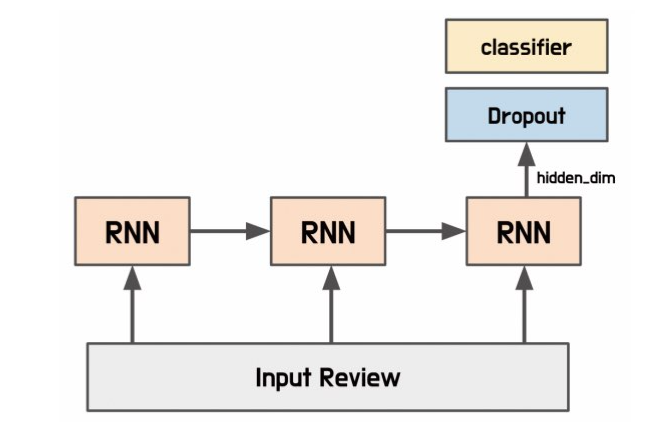

**<임베딩 계층>**

: 임베딩 벡터를 가져오는 임베딩 계층
- [어휘 사전의 크기 * 임베딩 벡터의 크기]로 순람표 구조를 가짐
- 입력 텍스트를 정수 인코딩 -> 해당 색인 값에 해당하는 임베딩을 가져오는 역할
- 초깃값
  - 1) 무작위 값 할당 -> 학습을 통해 임베딩 계층이 최적화되게 만듦
  - 2) 사전 학습된 임베딩 벡터를 가져와 사용

### 무작위 값으로 할당된 임베딩 계층으로 문장 분류 모델 구성

In [11]:
from torch import nn

class SentenceClassifier(nn.Module):
    # 입력: 임베딩 층을 구성할 때 사용하는 단어 사전 크기, 순환 신경망 클래스/장단기 메모리 클래스에서 사용하는 매개변수
    def __init__(
        self,
        n_vocab,
        hidden_dim,
        embedding_dim,
        n_layers,
        dropout=0.5,
        bidirectional=True,
        model_type="lstm" # 모델 종류 선택(RNN/LSTM)
    ):
        super().__init__()  # 부모 클래스(nn.Module)의 초기화 호출

        # ------------------------------------------------------------
        # 1) 임베딩 레이어: 단어 인덱스를 밀집 벡터로 변환
        #    - num_embeddings: 단어 집합 크기
        #    - embedding_dim: 각 단어 벡터의 차원
        #    - padding_idx=0: 패딩 토큰 인덱스 지정 (벡터가 0으로 고정)
        # ------------------------------------------------------------
        self.embedding = nn.Embedding(
            num_embeddings=n_vocab,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # ------------------------------------------------------------
        # 2) 순환 신경망 레이어 선택: RNN 또는 LSTM
        #    - 모델 구조 미세 조정
        #    - input_size: 임베딩 차원
        #    - hidden_size: 은닉 상태(hidden state)의 차원
        #    - num_layers: 레이어 개수
        #    - dropout: 레이어 간 드롭아웃 확률
        #    - bidirectional: 양방향 RNN 사용 여부
        #    - batch_first: 입력/출력 텐서 형태가 (batch, seq, features)
        # ------------------------------------------------------------
        if model_type == "rnn":
            # 기본 RNN 셀
            self.model = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=n_layers,
                dropout=dropout,
                bidirectional=bidirectional,
                batch_first=True
            )

        elif model_type == "lstm":
            # LSTM 셀 (장단기 기억)
            self.model = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=n_layers,
                dropout=dropout,
                bidirectional=bidirectional,
                batch_first=True
            )

        # ------------------------------------------------------------
        # 3) 분류기 설정: 양방향 여부에 따라 입력 차원 결정 후 선형 레이어 정의
        #    - hidden_dim: 단방향 은닉 차원
        #    - *2: 양방향일 경우 전방향+역방향 차원 합산
        #    - 출력 차원: 예측할 클래스 수(여기서는 1)
        # ------------------------------------------------------------
        if bidirectional:
            self.classifier = nn.Linear(hidden_dim * 2, 1)
        else:
            self.classifier = nn.Linear(hidden_dim, 1)

        # ------------------------------------------------------------
        # 4) 드롭아웃 레이어: 과적합 방지를 위해 일부 뉴런 무작위 비활성화
        # ------------------------------------------------------------
        self.dropout = nn.Dropout(dropout)



    def forward(self, inputs):
        # ------------------------------------------------------------
        # 입력: inputs (batch_size, seq_length) 형태의 단어 인덱스 텐서
        # ------------------------------------------------------------

        # 1) 임베딩 변환
        embeddings = self.embedding(inputs)
        #    결과: (batch_size, seq_length, embedding_dim)

        # 2) 순환 레이어 통과
        #    output: 모든 시점의 출력 (batch_size, seq_length, hidden_size * num_directions)
        #    hidden: 마지막 시점의 은닉 상태 (unused here)
        output, _ = self.model(embeddings)

        # 3) 마지막 시점 출력 선택
        #    - 양방향일 경우 양쪽 방향의 은닉이 합쳐진 차원
        last_output = output[:, -1, :]  # 마지막 시점의 결괏값만 분리 -> 분류기 계층에 전달

        # 4) 드롭아웃 적용
        last_output = self.dropout(last_output)

        # 5) 최종 로짓 계산
        logits = self.classifier(last_output)

        return logits  # (batch_size, num_classes)


#### 데이터세트 로드
- 코포라 라이브러리의 네이버 영화 리뷰 감정 분석 데이터세트

In [13]:
!pip install Korpora

In [14]:
import pandas as pd
from Korpora import Korpora

corpus = Korpora.load("nsmc")
corpus_df = pd.DataFrame(corpus.test) # 크기가 작은 테스트 데이터세트를 활용, corpus.test

train = corpus_df.sample(frac=0.9, random_state=42)
test = corpus_df.drop(train.index)

print(train.head(5).to_markdown)
print("Training Data Size: ", len(train))
print("Testing Data Size: ", len(test))


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : e9t@github
    Repository : https://github.com/e9t/nsmc
    References : www.lucypark.kr/docs/2015-pyconkr/#39

    Naver sentiment movie corpus v1.0
    This is a movie review dataset in the Korean language.
    Reviews were scraped from Naver Movies.

    The dataset construction is based on the method noted in
    [Large movie review dataset][^1] from Maas et al., 2011.

    [^1]: http://ai.stanford.edu/~amaas/data/sentiment/

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/

[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ratings_train.txt
[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ra

#### 토큰화, 단어 사전 구축
- Okt 토크나이저로 데이터세트 토큰화, 사전 구축

In [15]:
from konlpy.tag import Okt
from collections import Counter

def build_vocab(corpus, n_vocab, special_tokens):
  counter = Counter()
  for tokens in corpus:
    counter.update(tokens)
  vocab = special_tokens
  for token, count in counter.most_common(n_vocab):
    vocab.append(token)
  return vocab

tokenizer = Okt()
train_tokens = [tokenizer.morphs(review) for review in train.text]
test_tokens = [tokenizer.morphs(review) for review in test.text]

# 문장의 길이를 맞추기 위해 <pad> 토큰을 special_tokens에 추가
# 단어 사전 최대 길이 5000 + 특수 토큰 2개 = 단어 사전 5002개로 구성
vocab = build_vocab(corpus=train_tokens, n_vocab=5000, special_tokens=["<pad>", "<unk>"])

token_to_id = {token: idx for idx, token in enumerate(vocab)}
id_to_token = {idx: token for idx, token in enumerate(vocab)}

print(vocab[:10])
print(len(vocab))

['<pad>', '<unk>', '.', '이', '영화', '의', '..', '가', '에', '...']
5002


#### 정수 인코딩, 패딩
- 파이토치의 임베딩 층을 사용하기 위해 토큰을 정수로 변환
- 정수로 인코딩하면 모델이 텍스트 데이터를 처리하기 쉬워짐

In [16]:
import numpy as np

def pad_sequences(sequences, max_length, pad_value):
    """
    주어진 리스트 형태의 시퀀스들을 고정된 길이로 패딩하거나 자르는 함수

    Args:
        sequences (List[List[int]]): 단어 인덱스 리스트들의 리스트
        max_length (int): 시퀀스의 최대 길이
        pad_value (int): 패딩에 사용할 인덱스 값

    Returns:
        np.ndarray: (num_sequences, max_length) 형태의 패딩된 배열
    """
    result = list()  # 패딩된 시퀀스를 저장할 리스트
    for seq in sequences:
        # 1) 길이가 max_length보다 길면 자르기
        truncated = seq[:max_length]
        # max_length(최대 길이)는 입력 텍스트의 길이를 고려해 결정

        # 2) 부족한 길이만큼 pad_value로 채우기
        pad_len = max_length - len(truncated)
        padded = truncated + [pad_value] * pad_len

        # 3) 결과 리스트에 추가
        result.append(padded)

    # 리스트를 NumPy 배열로 변환하여 반환
    return np.asarray(result)

# ------------------------------------------------------------------
# 토큰을 정수 인덱스로 변환하고, 시퀀스 패딩 예시
# ------------------------------------------------------------------
unk_id = token_to_id.get("<unk>")  # 사전에 없는 토큰에 할당할 인덱스

# 학습용, 평가용 토큰 시퀀스를 정수 리스트로 변환
train_ids = [
    [token_to_id.get(token, unk_id) for token in review]
    for review in train_tokens
]
test_ids = [
    [token_to_id.get(token, unk_id) for token in review]
    for review in test_tokens
]

# 최대 시퀀스 길이 및 패딩 토큰 인덱스 설정
max_length = 32
pad_id = token_to_id.get("<pad>")

# 패딩 함수 호출
train_ids = pad_sequences(train_ids, max_length, pad_id)
test_ids = pad_sequences(test_ids, max_length, pad_id)

# 첫 번째 시퀀스 출력 확인
print(train_ids[0])
print(test_ids[0])


[ 223 1716   10 4036 2095  193  755    4    2 2330 1031  220   26   13
 4839    1    1    1    2    0    0    0    0    0    0    0    0    0
    0    0    0    0]
[3307    5 1997  456    8    1 1013 3906    5    1    1   13  223   51
    3    1 4684    6    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]


- OOV는 1로 인코딩
- 시퀀스 길이가 짧은 경우 최대 길이(32)가 될 수 있게 0(<pad>)를 추가

#### 데이터로더 적용

In [17]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1) NumPy 배열을 PyTorch 텐서로 변환하여 GPU/CPU 연산에 활용
train_ids = torch.tensor(train_ids)
test_ids = torch.tensor(test_ids)

# 2) 판다스 Series 형태의 레이블을 FloatTensor로 변환
#    - dtype=torch.float32: 손실 함수 계산을 위해 실수형 필요
train_labels = torch.tensor(train.label.values, dtype=torch.float32)
test_labels = torch.tensor(test.label.values, dtype=torch.float32)

# 3) TensorDataset 생성: 입력 데이터와 레이블을 하나의 데이터셋으로 묶음
# TensorDataset 클래스: 파이토치 텐서 형태를 입력값으로 받음
#   정수 인코딩과 라벨값을 파이토치 텐서 형태로 변환
#   변환된 데이터세트는 데이터로더 클래스에 적용
train_dataset = TensorDataset(train_ids, train_labels)
test_dataset = TensorDataset(test_ids, test_labels)

# 4) DataLoader 생성
#    - batch_size=16: 한 번에 처리할 샘플 수
#    - shuffle: 학습 시(True) 데이터 순서 랜덤화, 평가 시(False) 순서 유지
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


#### 손실 함수, 최적화 함수 정의
- 모델 학습을 위해 손실 함수와 최적화 함수 선언

In [18]:
from torch import optim
import torch
from torch import nn

# ------------------------------------------------------------
# 1) 하이퍼파라미터 설정
#    - n_vocab: 단어 사전 크기
#    - hidden_dim: RNN/LSTM 은닉 상태 차원
#    - embedding_dim: 임베딩 벡터 차원
#    - n_layers: 순환 레이어 개수
# ------------------------------------------------------------
n_vocab = len(token_to_id)
hidden_dim = 64 # 은닉 상태 크기
embedding_dim = 128 # 임베딩 벡터 크기
n_layers = 2  # 두 층의 신경망

# ------------------------------------------------------------
# 2) 연산 디바이스 설정
#    - GPU 사용 가능 시 'cuda', 아니면 'cpu'
# ------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------------------------
# 3) 모델 초기화 및 디바이스 할당
#    - SentenceClassifier 인스턴스 생성
#    - to(device): 모델 파라미터를 GPU/CPU 메모리로 이동
# ------------------------------------------------------------
classifier = SentenceClassifier(
    n_vocab=n_vocab,
    hidden_dim=hidden_dim,
    embedding_dim=embedding_dim,
    n_layers=n_layers
).to(device)

# ------------------------------------------------------------
# 4) 손실 함수 정의
#    - BCEWithLogitsLoss: 이진 분류를 위한 시그모이드 + Binary Cross Entropy
#         - BCELoss 클래스와 Sigmois 클래스가 결합된 형태
#         - BCELoss 클래스 사용하는 경우 criterion(torch.sigmoid(output), target)과 동일한 형태로 간주
#    - to(device): 손실 계산 시에도 디바이스 일관성 유지
# ------------------------------------------------------------
criterion = nn.BCEWithLogitsLoss().to(device)

# ------------------------------------------------------------
# 5) 옵티마이저 설정
#    - RMSprop: 학습률 적응형 알고리즘. 모든 기울기를 누적하지 않고 지수 가중 이동 평균을 사용해 학습률 조정
#         - 기울기 제곱 값의 평균값이 작아지면 학습률을 증가, 그 반대일 경우 학습률을 감소시킴
#         - 불필요한 지역 최솟값에 빠지는 것을 방지
#         - 기울기의 크기가 큰 경우에는 빠른 수렴을 보이며, 작은 경우에는 더 작은 학습률을 유지하여 더 안정적으로 최적화 수행
#    - classifier.parameters(): 모델 학습 대상 파라미터
#    - lr=0.001: 학습률 설정
# ------------------------------------------------------------
optimizer = optim.RMSprop(classifier.parameters(), lr=0.001)


#### 모델 학습, 테스트
- 에포크마다 테스트 데이터세트로 모델의 검증 손실, 검증 정확도를 확인

In [19]:
import numpy as np
import torch

# ------------------------------------------------------------
# 1) 학습 함수 정의
#    - model: 훈련할 신경망 모듈
#    - datasets: DataLoader(입력, 레이블) 튜플
#    - criterion: 손실 함수
#    - optimizer: 최적화 알고리즘
#    - device: 'cuda' or 'cpu'
#    - interval: 출력할 로스 프린트 주기
# ------------------------------------------------------------
def train(model, datasets, criterion, optimizer, device, interval):
    # 훈련 모드 활성화: 드롭아웃, 배치 정규화 등 학습용 동작
    model.train()
    losses = []  # 각 스텝의 손실을 저장할 리스트

    # 배치 단위 반복
    for step, (input_ids, labels) in enumerate(datasets):
        # 1) 텐서를 지정 디바이스(GPU/CPU)로 이동
        input_ids = input_ids.to(device)
        # (batch_size,) -> (batch_size, 1) 형태로 차원 확장
        labels = labels.to(device).unsqueeze(1)

        # 2) 순전파: 모델에 입력하여 로짓(logits) 계산
        logits = model(input_ids)
        # 3) 손실 계산
        loss = criterion(logits, labels)
        losses.append(loss.item())  # Python float로 변환하여 저장

        # 4) 역전파 및 파라미터 업데이트
        optimizer.zero_grad()  # 이전 기울기 초기화
        loss.backward()        # 기울기 계산
        optimizer.step()       # 가중치 업데이트

        # 5) 지정한 interval마다 평균 손실 출력
        if step % interval == 0:
            print(f"Train Loss Step {step}: {np.mean(losses):.4f}")


# ------------------------------------------------------------
# 2) 평가 함수 정의
#    - model: 평가할 신경망 모듈
#    - datasets: DataLoader(입력, 레이블)
#    - criterion: 손실 함수
#    - device: 'cuda' or 'cpu'
# ------------------------------------------------------------
def test(model, datasets, criterion, device):
    # 평가 모드 활성화: 드롭아웃 비활성화 등
    model.eval()
    losses = []    # 손실 저장
    corrects = []  # 정확도 계산용 저장소

    # 기울기 계산 비활성화(메모리 절약, 속도 개선)
    with torch.no_grad():
        for step, (input_ids, labels) in enumerate(datasets):
            # 디바이스로 이동 및 차원 확장
            input_ids = input_ids.to(device)
            labels = labels.to(device).unsqueeze(1)

            # 순전파 및 손실 계산
            logits = model(input_ids)
            loss = criterion(logits, labels)
            losses.append(loss.item())

            # 로짓에 시그모이드 적용 후 임계값 0.5로 이진 분류 예측
            preds = torch.sigmoid(logits) > 0.5
            # 예측값과 실제값 비교 후 리스트에 확장
            corrects.extend(torch.eq(preds, labels).cpu().tolist())

    # 전체 손실과 정확도 출력
    print(f"Val Loss: {np.mean(losses):.4f}, Val Accuracy: {np.mean(corrects):.4f}")


# ------------------------------------------------------------
# 3) 학습/평가 루프 설정 및 실행
# ------------------------------------------------------------
epochs = 5      # 총 훈련 반복 횟수
interval = 500  # 로스 출력 주기

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    train(classifier, train_loader, criterion, optimizer, device, interval)
    test(classifier, test_loader, criterion, device)



Epoch 1/5
Train Loss Step 0: 0.6797
Train Loss Step 500: 0.6932
Train Loss Step 1000: 0.6824
Train Loss Step 1500: 0.6746
Train Loss Step 2000: 0.6716
Train Loss Step 2500: 0.6652
Val Loss: 0.6465, Val Accuracy: 0.6104

Epoch 2/5
Train Loss Step 0: 0.7031
Train Loss Step 500: 0.6288
Train Loss Step 1000: 0.6093
Train Loss Step 1500: 0.5952
Train Loss Step 2000: 0.5908
Train Loss Step 2500: 0.5820
Val Loss: 0.5213, Val Accuracy: 0.7428

Epoch 3/5
Train Loss Step 0: 0.3264
Train Loss Step 500: 0.4830
Train Loss Step 1000: 0.4811
Train Loss Step 1500: 0.4750
Train Loss Step 2000: 0.4695
Train Loss Step 2500: 0.4623
Val Loss: 0.4342, Val Accuracy: 0.7994

Epoch 4/5
Train Loss Step 0: 0.2742
Train Loss Step 500: 0.3905
Train Loss Step 1000: 0.3925
Train Loss Step 1500: 0.3926
Train Loss Step 2000: 0.3898
Train Loss Step 2500: 0.3911
Val Loss: 0.4085, Val Accuracy: 0.8086

Epoch 5/5
Train Loss Step 0: 0.2008
Train Loss Step 500: 0.3486
Train Loss Step 1000: 0.3493
Train Loss Step 1500: 0.35

### 사전 학습된 임베딩 벡터를 가져와 사용
- 학습된 임베딩 계층의 가중치를 동일한 단어 사전을 사용하는 토큰의 임베딩 값으로 사용

#### 학습된 모델로부터 임베딩 추출

In [20]:
token_to_embedding = dict()
embedding_matrix = classifier.embedding.weight.detach().cpu().numpy()

for word, emb in zip(vocab, embedding_matrix):
  token_to_embedding[word] = emb

token = vocab[1000]
print(token, token_to_embedding[token])

보고싶다 [ 0.2741189   1.5933132   0.9811079   0.7256053  -0.33354682 -0.29734892
  0.6414464  -2.0788276   1.9724951  -0.33713284  0.8164797   0.3744198
 -0.07929122 -1.376289    3.9490852   0.49848118  0.8453304  -0.60377485
  0.29956523  0.5435477   0.45151734  0.2737446  -2.4557698  -0.391179
  1.125487    0.18419528 -1.1502478  -0.46748322 -1.6038718   0.3541617
 -0.712157    0.54646415  1.6962551   0.36206922 -1.4532988   1.0172818
 -1.0433451   0.8365936   0.6587463   0.834962    1.1092188   0.630006
  0.697199    0.14233804 -0.6714227  -0.65408826  0.4711452   2.0588913
 -0.24136432 -1.0310477   0.3139379   0.35726443 -0.967933   -0.49588007
  0.88731575 -0.6661675  -0.65730566  0.10681643 -1.4858398   0.57512194
  0.6421214  -1.3372043  -0.28543243  1.3286139  -0.19808675 -1.9141785
  1.2318832  -1.0342194  -0.94167596  1.8802035  -0.46805182  0.78295064
 -1.3676472  -0.8037413  -1.8688382   0.18581164  2.0303996  -0.726511
  0.19693731 -0.24086085 -1.2526522  -0.0612039  -0.33020

- 학습된 모델의 임베딩 계층을 각 단어에 대한 임베딩으로 사용할 수 있음
- 긍/부정 분류는 임베딩 계층이 아닌 순환 신경망의 연산이 더 중요하게 동작
- 모델이 복잡할수록 임베딩 계층이 토큰의 의미 정보를 학습하기는 더 어려움

#### 사전 학습된 모델로 임베딩 계층 초기화
- Word2Vec 모델로 임베딩 계층을 초기화

In [40]:
import numpy as np
import torch
from torch import nn
import fasttext

# ------------------------------------------------------------------
# 1) 임베딩 행렬 초기화용 설정
# ------------------------------------------------------------------
# 토크나이저에서 뽑은 단어 사전과 인덱스 맵
# token_to_id: {'<pad>':0, '<unk>':1, '영화':2, ...}
# id_to_token: {0:'<pad>', 1:'<unk>', 2:'영화', ...}
n_vocab = len(token_to_id)
embedding_dim = ft_model.get_dimension()  # FastText 벡터 차원

# 0으로 채운 초기 행렬 생성
init_embeddings = np.zeros((n_vocab, embedding_dim), dtype=np.float32)

# ------------------------------------------------------------------
# 2) 단어별 벡터 대입
#    - '<pad>'와 '<unk>'는 0 벡터 유지
# ------------------------------------------------------------------
for idx, token in id_to_token.items():
    if token in ('<pad>', '<unk>'):
        continue
    init_embeddings[idx] = ft_model.get_word_vector(token)

# ------------------------------------------------------------------
# 3) nn.Embedding 레이어 생성 및 초기화
#    - padding_idx: 패딩 토큰 인덱스 지정하여 gradient 0 고정
#    - freeze=False로 설정하면 학습 중 임베딩 미세조정(fine-tuning) 가능
# ------------------------------------------------------------------
embedding_layer = nn.Embedding.from_pretrained(
    torch.from_numpy(init_embeddings),
    freeze=False,
    padding_idx=pad_id
)

In [45]:
import torch
from torch import nn

class SentenceClassifier(nn.Module):
    # 입력: 임베딩 층, RNN/LSTM 설정, 사전학습 임베딩(optional), 패딩 인덱스 지정
    def __init__(
        self,
        n_vocab,
        hidden_dim,
        embedding_dim,
        n_layers,
        dropout=0.5,
        bidirectional=True,
        model_type="lstm",   # 모델 종류 선택(RNN/LSTM)
        pretrained_embedding=None,  # numpy array 또는 torch Tensor (optional)
        pad_idx=0,                  # 패딩 토큰 인덱스
    ):
        super().__init__()

        # ------------------------------------------------------------
        # 검증: 임베딩 크기와 vocab 일치 여부 확인
        # ------------------------------------------------------------
        if pretrained_embedding is not None:
            emb_size = (
                pretrained_embedding.shape[0]
                if not isinstance(pretrained_embedding, torch.Tensor)
                else pretrained_embedding.size(0)
            )
            assert emb_size == n_vocab, \
                f"pretrained_embedding rows ({emb_size}) must equal n_vocab ({n_vocab})"

        # ------------------------------------------------------------
        # 1) 임베딩 레이어: 사전학습 벡터 활용 또는 랜덤 초기화
        # ------------------------------------------------------------
        if pretrained_embedding is not None:
            emb_tensor = (
                torch.tensor(pretrained_embedding, dtype=torch.float32)
                if not isinstance(pretrained_embedding, torch.Tensor)
                else pretrained_embedding
            )
            self.embedding = nn.Embedding.from_pretrained(
                emb_tensor,
                freeze=False,        # 학습 중 임베딩 미세조정
                padding_idx=pad_idx  # 패딩 인덱스 지정
            )
        else:
            self.embedding = nn.Embedding(
                num_embeddings=n_vocab,
                embedding_dim=embedding_dim,
                padding_idx=pad_idx   # 패딩 인덱스 지정
            )

        # ------------------------------------------------------------
        # 2) 순환 신경망 레이어 선택: RNN 또는 LSTM
        # ------------------------------------------------------------
        if model_type == "rnn":
            self.model = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=n_layers,
                dropout=dropout,
                bidirectional=bidirectional,
                batch_first=True
            )
        else:
            self.model = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=n_layers,
                dropout=dropout,
                bidirectional=bidirectional,
                batch_first=True
            )

        # ------------------------------------------------------------
        # 3) 분류기 설정: 양방향 여부에 따라 차원 조정
        # ------------------------------------------------------------
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.classifier = nn.Linear(output_dim, 1)

        # ------------------------------------------------------------
        # 4) 드롭아웃 레이어: 과적합 방지
        # ------------------------------------------------------------
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        # ------------------------------------------------------------
        # 입력: (batch_size, seq_length) 단어 인덱스 텐서
        # ------------------------------------------------------------
        embeddings = self.embedding(inputs)
        # (batch, seq, emb_dim)

        output, _ = self.model(embeddings)
        # output: (batch, seq, hidden*num_directions)

        last_output = output[:, -1, :]
        # 마지막 시점 벡터 추출

        dropped = self.dropout(last_output)
        logits = self.classifier(dropped)

        return logits  # (batch_size, 1)


In [50]:
# 오류 해결이 안돼요ㅠㅠ

device = torch.device("cpu")
# 데이터 처리 시
pad_idx = token_to_id.get("<pad>", 0)
train_ids = pad_sequences(train_ids, max_length, pad_id)
# 모델 생성 시
classifier = SentenceClassifier(
    n_vocab=n_vocab,
    hidden_dim=hidden_dim,
    embedding_dim=embedding_dim,
    n_layers=n_layers,
    pretrained_embedding=init_embeddings,
    pad_idx=pad_idx         # <-- 같은 값 사용
).to(device)

criterion = nn.BCEWithLogitsLoss().to(device)
optimizer = optim.RMSprop(classifier.parameters(), lr=0.001)

epochs = 5
interval = 500

for epoch in range(epochs):
    train(classifier, train_loader, criterion, optimizer, device, interval)
    test(classifier, test_loader, criterion, device)


TypeError: unsupported operand type(s) for +: 'Tensor' and 'list'

- 사전 학습된 임베딩을 사용하는 것은 모델 성능을 개선할 수 있는 방법 중 하나
- 학습 데이터의 양이 충분히 많다면, 모델의 목적에 맞게 새로운 임베딩 층을 학습하는 것이 더 좋은 결과를 얻을 수도 있음
- 사전 학습된 임베딩을 사용하더라도 해당 언어와 문제에 맞는 임베딩을 선택하는 것이 중요
- 모델의 목적과 데이터의 특성을 고려하여 적절한 임베딩 방법을 선택

# 6.8. 합성곱 신경망

## 합성곱 모델

In [51]:
import torch
from torch import nn

class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Sequential(
        nn.Conv2d(
            in_channels=3, out_channels=16, kernel_size=3, stride=2, padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.conv2 = nn.Sequential(
        nn.Conv2d(
            in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    # 완전 연결 계층
    #   - 선형 변환으로 구성, 입력 벡터*가중치로 계산
    #   - 입력 데이터 차원 크기: 마지막 특징 맵의 높이*너비*채널
    #   - 출력 데이터 차원 크기 => 분류 모델의 클래스 개수
    self.fc = nn.Linear(32*32*32, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = torch.flatten(x)
    x = self.fc(x)
    return x

## 모델 실습
- 사전 학습된 임베딩 벡터를 사용하는 것이 일반적

### 합성곱 기반 분류 모델 정의

In [52]:
import torch
from torch import nn

class SentenceClassifier(nn.Module):
    """
    CNN 기반 문장 분류기 클래스
    - 사전 학습된 임베딩을 활용하여 단어 벡터 생성
    - 다양한 크기의 1D 합성곱 필터로 특징 추출
    - 추출된 특징을 선형 계층으로 분류
    """
    def __init__(self, pretrained_embedding, filter_sizes, max_length, dropout=0.5):
      # 사전 학습된 임베딩 벡터, 필터 크기 리스트, 최대 길이를 입력
        super().__init__()
        # ------------------------------------------------------------
        # 1) 사전 학습된 임베딩 로드 및 nn.Embedding 생성
        #    pretrained_embedding: numpy array 또는 torch.Tensor
        #    freeze=False: 임베딩을 학습 중에도 업데이트함
        # ------------------------------------------------------------
        emb_tensor = (
            # numpy array인 경우 Tensor로 변환
            torch.tensor(pretrained_embedding, dtype=torch.float32)
            if not isinstance(pretrained_embedding, torch.Tensor)
            else pretrained_embedding
        )
        self.embedding = nn.Embedding.from_pretrained(
            emb_tensor,  # (vocab_size, emb_dim)
            freeze=False # fine-tuning 허용
        )
        # 임베딩 차원 추출 (벡터 길이)
        embedding_dim = self.embedding.weight.shape[1]

        # ------------------------------------------------------------
        # 2) 합성곱(Conv1d) 필터 리스트 구성
        #    filter_sizes: 사용할 커널(윈도우) 크기 리스트
        #    max_length: 입력 시퀀스 최대 길이
        #    각 필터 후 ReLU, MaxPool1d로 차원 축소
        # ------------------------------------------------------------
        conv = []  # 각 크기의 필터를 담을 리스트
        for size in filter_sizes:
            conv.append(
                nn.Sequential(  # 필터 크기 리스트만큼 시퀀셜 생성
                    # 1D 합성곱: 입력 채널=임베딩 차원, 출력 채널=1
                    nn.Conv1d(
                        in_channels=embedding_dim,
                        out_channels=1,
                        kernel_size=size
                    ),
                    # 비선형 활성화 함수
                    nn.ReLU(),
                    # 풀링: 시퀀스 길이를 (max_length-size+1) -> 1로 축소
                    nn.MaxPool1d(kernel_size=max_length - size + 1)
                )
            )
        # ModuleList로 변환하여 nn.Module에 등록
        # ModuleList: 여러 개의 서브 모듈을 리스트 형태로 저장
        self.conv_filters = nn.ModuleList(conv)

        # ------------------------------------------------------------
        # 3) 분류 계층 설정
        #    output_size: 필터 개수 == 특징 벡터 길이
        #    pre_classifier: 특징 벡터 변환용 선형 계층
        #    dropout: 과적합 방지용 드롭아웃
        #    classifier: 최종 로짓 계산용 선형 계층
        # ------------------------------------------------------------
        output_size = len(filter_sizes)
        self.pre_classifier = nn.Linear(output_size, output_size)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(output_size, 1)  # 이진 분류용 출력

    def forward(self, inputs):
        """
        순전파 메서드
        Args:
            inputs (Tensor): 토큰 인덱스 텐서, shape=(batch_size, seq_length)
        Returns:
            logits (Tensor): 분류 로짓, shape=(batch_size, 1)
        """
        # ------------------------------------------------------------
        # 1) 임베딩 변환
        #    inputs: (batch, seq_len) -> embeddings: (batch, seq_len, emb_dim)
        # ------------------------------------------------------------
        embeddings = self.embedding(inputs)

        # ------------------------------------------------------------
        # 2) Conv1d를 위해 차원 순서 변경
        #    Conv1d expects (batch, channels, seq_length)
        #    embeddings: (batch, emb_dim, seq_len)
        # ------------------------------------------------------------
        embeddings = embeddings.permute(0, 2, 1)

        # ------------------------------------------------------------
        # 3) 각 필터별 특징 추출 및 풀링
        #    conv_outputs: 리스트 안의 요소는 모두 (batch, 1, 1)
        # ------------------------------------------------------------
        conv_outputs = [conv(embeddings) for conv in self.conv_filters]

        # ------------------------------------------------------------
        # 4) 풀링 결과를 squeeze하여 (batch, 1) -> (batch,)로 변환 후
        #    여러 필터 결과를 concat하여 (batch, output_size) 생성
        # ------------------------------------------------------------
        concat_outputs = torch.cat([out.squeeze(-1) for out in conv_outputs], dim=1)

        # ------------------------------------------------------------
        # 5) 분류기 파이프라인: pre_classifier -> dropout -> classifier
        # ------------------------------------------------------------
        x = self.pre_classifier(concat_outputs)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits  # shape=(batch_size, 1)


### 모델 학습

In [54]:
# 오류 해결이 안돼요ㅠㅠ

device = "cude" if torch.cuda.is_available() else "cpu"
filter_size = [3, 3, 4, 4, 5, 5]
classifier = SentenceClassifier(
    pretrained_embedding=init_embeddings,
    filter_sizes=filter_size,
    max_length=max_length
).to(device)

criterion = nn.BCEWithLogitsLoss().to(device)
# Adam 사용
#   - 경사 하강법 알고리즘을 개선한 방법
#   - 이전 기울기 값의 지수 이동 평균과 이전 기울기 값의 지수 이동 제곱 평균을 사용해 현재 기울기 값을 갱신
#   - 기울기가 빠르게 변화하는 구간에서 더 안정적인 수렴을 보임
#   - RMSProp과 같이 학습률을 조절해 발산하는 경우를 방지
#   - 하이퍼파라미터 조정하는 수고를 덜어줌
#   - 학습률, 모멘텀 조절 문제를 해결하여 SGD보다 빠른 수렴을 보이는 경우가 많음
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

epochs = 5
interval = 500

for epoch in range(epochs):
    train(classifier, train_loader, criterion, optimizer, device, interval)
    test(classifier, test_loader, criterion, device)


RuntimeError: Expected one of cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, maia, xla, lazy, vulkan, mps, meta, hpu, mtia, privateuseone device type at start of device string: cude